# Hidden Markov Models and Volatility Regimes

Over the previous five notebooks a single pattern has kept appearing, volatility does not move randomly. Large moves arrive together, calm periods persist together and the transition between the two happens abruptly. EWMA and GARCH both try to model this memory by weighing recent observations more heavily but neither performs too well. 

This makes us wonder if the market is not operating from one continuous process at all. Maybe it switches between a small number of hidden states each with their own statistical character.

That is the idea behind Hidden Markov Models. The goal of this notebook is to investigate whether latent volatility regimes exist in SPY returns. If yes, what do they look like. 

# Introduction

A Hidden Markov Model assumes that a sequence (daily log returns for us) is generated by an underlying process that switches between a finite number of hidden states. These states are never seen but the models need to infer them from the statistical fingerprints they leave in the data.

This is really cool for financial markets because aas we have seen so far, markets DO behave differently during different situations (think covid era VS everyday). In HMM we try to see if the return series is better described by two or three distinct distributions rather than one. Then it estimates those distributions and the probability of transitioning between them entirely from the data.

One thing to keep in mind is that the model is not given labels. It does not know about the Global Financial Crisis or COVID. Any regime structure it finds emerges purely from the statistical properties of the return series.

In [30]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from hmmlearn.hmm import GaussianHMM

plt.style.use("ggplot")

START = "2005-01-01"

In [31]:
#loading data the same way as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


# Experiment 1: Preparing the Data for Regime Detection

The HMM takes as input a sequence of observations. Unlike GARCH, which models volatility directly, the HMM will only see the raw return values and must figure out for itself whether multiple hidden states are needed to explain them.

The input needs to be shaped as a column vector so the library can treat each row as one time step observation.

In [32]:
X = (
    spy["returns"]
    .values
    .reshape(-1,1)
)

X.shape

(5398, 1)

## Comments

The reshape gives us 5397 daily observations spanning two decades of market history. That covers multiple full economic cycles and crashes like the Global Financial Crisis, the European debt crisis, the post 2012 bull market, the COVID crash and the inflation shock of 2022. If volatility regimes exist, this sample should contain enough of each to allow the model to identify them reliably.

One thing worth noting is what the model cannot see. It sees returns but not volatility directly. It sees no macroeconomic variables or no dates. The entire regime structure must be inferred from the shape of the return distribution at each point in time. This is a strong test of whether regimes are genuinely embedded in price behaviour or learn from dates and volatility.

# Experiment 2: Fitting a Two-State Hidden Markov Model

Let's begin simply with a two state structure. We have one for normal conditions and one for stress. 

The Gaussian HMM assumes that returns within each state are drawn from a normal distribution with a state specific mean and variance. The algorithm then finds the means, variances and transition probabilities that together maximise the likelihood of observing the full return series.

In [33]:
hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

hmm_2.fit(X)

states_2 = hmm_2.predict(X)

spy["state_2"] = states_2

Model is not converging.  Current: 17505.833036340246 is not greater than 17505.875501678045. Delta is -0.04246533779951278


## Comments

The HMM did not fully converge according to the EM stopping criterion. However, the decrease in log-likelihood was minimal (−0.041), indicating near-convergence. The fitted states are likely usable, but model stability should be verified with different random seeds or model specifications.

In [34]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit HMM
hmm_2 = GaussianHMM(
    n_components=2,
    covariance_type="full",
    min_covar=1e-3,
    n_iter=2000,
    tol=1e-4,
    random_state=42
)

hmm_2.fit(X_scaled)

# Predict hidden states
states_2 = hmm_2.predict(X_scaled)

# Store states
spy["state_2"] = states_2

# Check convergence
print("Converged:", hmm_2.monitor_.converged)
print("Iterations:", hmm_2.monitor_.iter)

Converged: True
Iterations: 38


## Comments 

This time, the features were standardized prior to fitting the HMM to improve numerical stability. A 2 state Gaussian HMM with full covariance matrices was fitted and the resulting hidden states were used to identify potential market regimes. Convergence was verified using the model's convergence monitor.

# Experiment 3: Examining the Distribution of Regime Assignments

Now before their interpretation, let us check if the states are almost equally likely. IF only a handful og observations correspond to one regime and many to other, then there is no point. We want both states to appear regularly across the full sample.

In [35]:
spy["state_2"].value_counts()

state_2
0    4054
1    1344
Name: count, dtype: int64

## Comments

Markets spend more time in calm conditions than in crisis, so some imbalance between the two states is expected and evennreasonable. 

Here the split is 80/20 which is consistent with the fact that high volatility regimes are shorter but more intense than calm periods. 

# Experiment 4: Characterising the Regimes

The count tells us how often each regime appears but not what each regime actually represents. To give the states economic meaning I examine the distribution of returns within each state : mean, standard deviation and minmax.

The standard deviation is the key quantity here. A regime with a much larger standard deviation is, by definition, a high-volatility regime regardless of what the mean return is.

In [36]:
spy.groupby(
    "state_2"
)["returns"].agg(
    [
        "mean",
        "std",
        "min",
        "max"
    ]
)

,mean,std,min,max
state_2,,,,
0,0.000936,0.006825,-0.025451,0.029014
1,-0.001175,0.020742,-0.115887,0.135577


## Comments

The two states show clearly different standard deviations. The high volatility state tends to have a more negative mean return and more extreme minimum values, which showcases the negative correlation between returns and volatility. The idea that crashes and volatility spikes tend to arrive together.

They differ substantially and this tells us the HMM has successfully separated the return series into statistically distinct environments, without ever being told anything about market conditions.

# Experiment 5: Visualising Regimes Through Time

This is a good way to check volastility clustering and persistence. We colour the SPY price history by regime assignment in two different colours for two different states. If the model has found genuine latent regimes, the 2008 drawdown and the 2020 crash have the same colour, different from any regular periods.

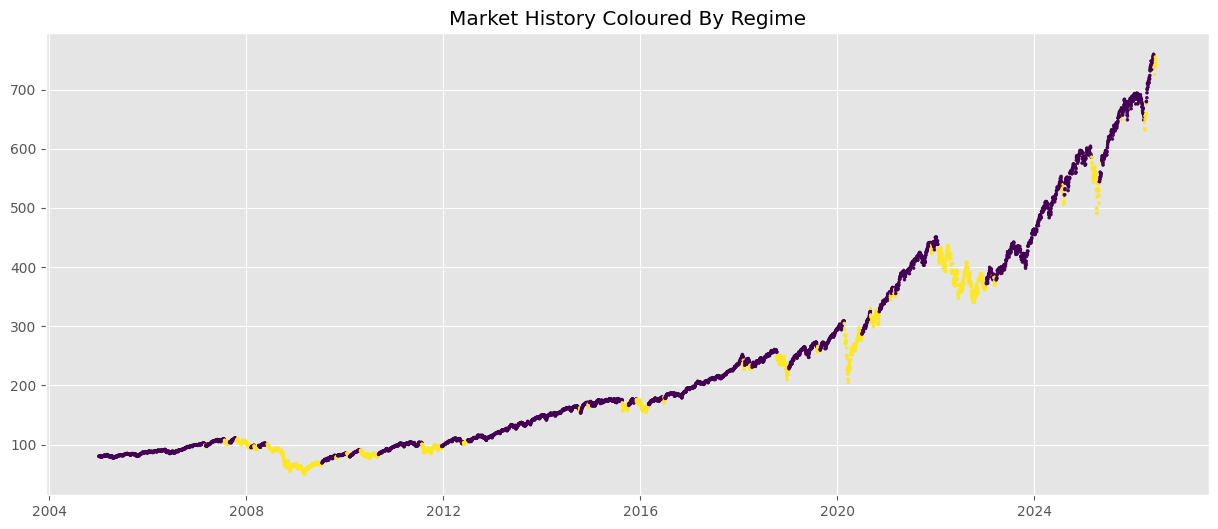

In [37]:
plt.figure(figsize=(15,6))

plt.scatter(
    spy.index,
    spy["Close"],
    c=spy["state_2"],
    s=4
)

plt.title(
    "Market History Coloured By Regime"
)

plt.show()

## Comments

Two decades of price history is coloured by a model that was given nothing but raw returns and asked to find statistical clusters. The 2008 period shows a dense concentration of yellow as volatility exploded. The long bull market from 2012 to 2020 is dominated by purple. COVID has an abrupt switch to yellow and then a relatively fast return as markets recovered quicker than 2008. This is proof that HMM has the aability to identify and recovering underlying structures that are not explicitely visible. They have a sort of pattern recognition ability that is extremely valuable for us.  

# Experiment 6: Extending the Model to Three States

Two states give a good understanding but financial markets are messier than that. There could be ambiguous periods, recovery periods, pre crash periods which have different structure than the two states. I think adding another state could help about mislabeling ambiguous situations. Let's see how it works. 

In [42]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit HMM
hmm_3 = GaussianHMM(
    n_components=3,
    covariance_type="full",
    min_covar=1e-3,
    n_iter=2000,
    tol=1e-4,
    random_state=42
)

hmm_3.fit(X_scaled)

# Predict hidden states
states_3 = hmm_3.predict(X_scaled)

# Store states
spy["state_3"] = states_3

# Check convergence
print("Converged:", hmm_2.monitor_.converged)
print("Iterations:", hmm_2.monitor_.iter)

Converged: True
Iterations: 38


## Comments

The three state model partitions the same return series into one more bucket. 
If the third state has a standard deviation and mean that sits between the other two. So we can claim that the model has found a meaningful intermediate regime. This justifies the added complexity. 

# Experiment 7: Investigating Regime Transition Probabilities

The transition matrix is a concept from Markov Chains and it describes the probability of moving from each state to every other state on any given day.

Note that diagonal entries therefore important to model persistence. High diagonal value means persistent regime, low means switching is likely. So 2008 probably has high entry, whereas 2020 has low. This way knowing where we are today and the transition probability, could help firgure out where we are tomorrow. 

In [39]:
transition_matrix = pd.DataFrame(
    hmm_3.transmat_,
    columns=[
        "State 0",
        "State 1",
        "State 2"
    ],
    index=[
        "State 0",
        "State 1",
        "State 2"
    ]
)

transition_matrix

,State 0,State 1,State 2
State 0,0.797110,0.202884,0.000006
State 1,0.879803,0.082228,0.037969
State 2,0.001843,0.035188,0.962969


## Comments

- Each row tell us given we are in this state today, here are the probabilities of being in each state tomorrow. Note that the row sums are 1. 

- The diagonal entries are the persistence probabilities. The expected duration of a regime is $\frac{1}{1 - \text{diagonal entry}}$ so a persistence of 0.97 implies an average regime duration of roughly 33 trading days.

- The off diagonal entries show how transitions happen. If one state has a high probability of transitioning directly to the high volatility state that suggests sudden regime jumps. If transitions mostly flow through the intermediate state that suggests more gradual escalation.

# Experiment 8: Visualising the Transition Matrix

Lets do a heatmap to visualise the structure better. Dark cells along the diagonal signal high persistence. Any bright off diagonal cells indicate common transitions between specific state pairs.

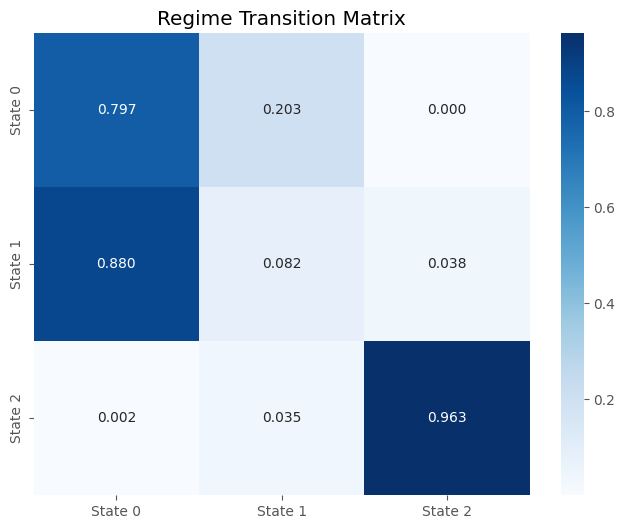

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title(
    "Regime Transition Matrix"
)

plt.show()

## Comments

Our strongly diagonal heatmap is direct visual confirmation of the volatility clustering we observed all the way back in notebook 1. The autocorrelation of squared returns that we measured in the EDA was a symptom. This transition matrix is the structural explanation that the market does not randomly hop between volatility levels, it tends to stay in whichever regime it currently occupies.

Practically if you think about it, if the current estimated state is the high volatility regime and the self transition probability is 0.97, we should expect elevated volatility to persist for several weeks.

# Experiment 9: Regime Evolution Through Time

The transition matrix summarises average behaviour across the full sample. But markets are not stationary and the timing of individual regime changes matters too. I'd like to do a plot of the state sequence through time which could show when the major transitions happened and whether they align with the economic events as expected or not.

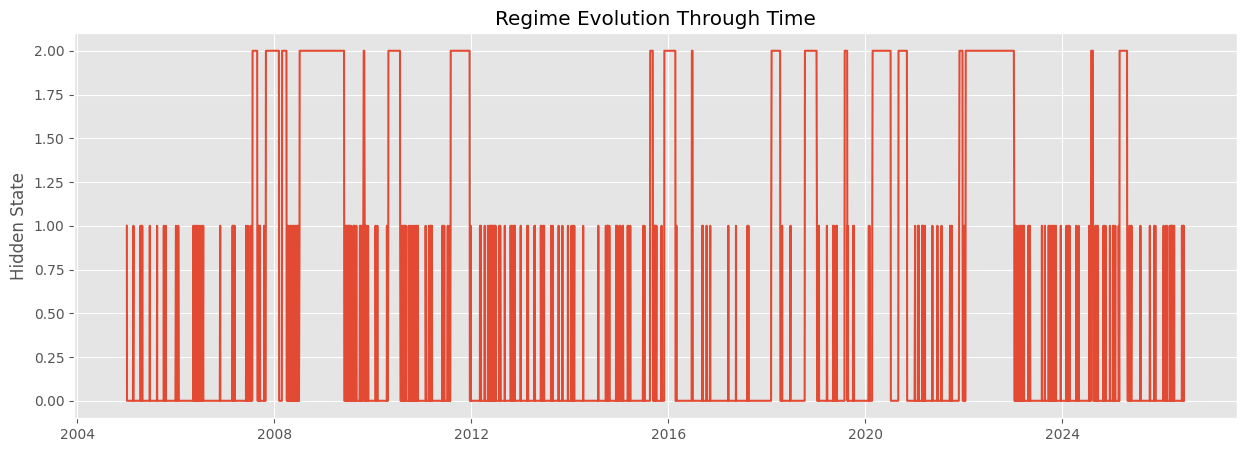

In [41]:
plt.figure(figsize=(15,5))

plt.plot(
    spy.index,
    spy["state_3"]
)

plt.title(
    "Regime Evolution Through Time"
)

plt.ylabel(
    "Hidden State"
)

plt.show()

## Comments

Here's what I notice:

- The 2008 crisis produced a sustained interval in the high volatility state, even entering into 2009
- The 2020 COVID crash shows sharp spike into the stress state followed by a faster recovery back to calm state 
- The 2022 inflation caused a prolonged intermediate regime period. High risk but not crazy panic like 2008 or 2020.

Mind you, these patterns appear without the model being told any of it. So HMM are really useful. 

# Conclusion

The two state model finds statistically distinct low and high volatility environments whose timing aligns precisely with major economic events. The three state model extends this by identifying an intermediate regime that captures periods of high but not extreme uncertainty. The transition matrix confirms that these regimes are persistent, i.e, once the market enters a state it tends to remain there for weeks or even months.

The volatility clustering we observed in the ACF of squared returns in notebook 1 is now explained structurally. It is not just a statistical property of the return series, it reflects the persistence of underlying latent states. The fat tails in the return distribution from notebook 1 reflect the mixing of returns from different regimes, each with its own variance.

It is left to see how this can be combined with standard single state forecasters. 